# Disparate Impact Analysis (DIA) Explainer Demo

This example demonstrates how to interpret a **scikit-learn** model using
the H2O Sonar library and retrieve the data and plot the **Disparate Impact Analysis**.

In [1]:
import logging

import pandas
import webbrowser

from h2o_sonar import interpret
from h2o_sonar.lib.api import commons, explainers
from h2o_sonar.explainers.dia_explainer import DiaExplainer
from h2o_sonar.lib.api.models import ModelApi

from sklearn.ensemble import GradientBoostingClassifier

In [2]:
results_location = "../../results"

# dataset
dataset_path = "../../data/predictive/creditcard.csv"
target_col = "default payment next month"
df = pandas.read_csv(dataset_path)
(X, y) = df.drop(target_col, axis=1), df[target_col]

In [3]:
# parameters
interpret.describe_explainer(DiaExplainer)

{'id': 'h2o_sonar.explainers.dia_explainer.DiaExplainer',
 'name': 'DiaExplainer',
 'display_name': 'Disparate Impact Analysis',
 'tagline': 'DiaExplainer.',
 'description': 'Disparate Impact Analysis (DIA) is a technique that is used to evaluate fairness. Bias can be introduced to models during the process of collecting, processing, and labeling data as a result, it is important to determine whether a model is harming certain users by making a significant number of biased decisions. DIA typically works by comparing aggregate measurements of unprivileged groups to a privileged group. For instance, the proportion of the unprivileged group that receives the potentially harmful outcome is divided by the proportion of the privileged group that receives the same outcome - the resulting proportion is then used to determine whether the model is biased.',
 'brief_description': 'DiaExplainer.',
 'model_types': ['iid', 'time_series'],
 'can_explain': ['regression', 'binomial'],
 'explanation_sco

## Interpret

In [4]:
# scikit-learn model
gradient_booster = GradientBoostingClassifier(learning_rate=0.1)
gradient_booster.fit(X, y)

# explainable model
model = ModelApi().create_model(target_col=target_col, model_src=gradient_booster, used_features=X.columns.to_list())

interpretation = interpret.run_interpretation(
    dataset=df,
    model=model,
    target_col=target_col,
    results_location=results_location,
    log_level=logging.INFO,
    explainers=[
        commons.ExplainerToRun(
            explainer_id=DiaExplainer.explainer_id(),
            params="",
        )
    ]
)

/home/user/h/mli/git/h2o-sonar-FLOSS/.venv/lib/python3.11/site-packages/ragas/metrics/__init__.py:1: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  from ragas.metrics._answer_correctness import AnswerCorrectness, answer_correctness
/home/user/h/mli/git/h2o-sonar-FLOSS/.venv/lib/python3.11/site-packages/ragas/metrics/__init__.py:4: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain.pydantic_v1 module was a compatibility shim for pydantic 

Preparing and checking DIA features (None): dataset=     | PAY_0  PAY_4  BILL_AMT2    AGE  PAY_3  EDUCATION  BILL_AMT1  PAY_AMT2    SEX  PAY_AMT5  …  PAY_AMT4  PAY_AMT6  BILL_AMT3  LIMIT_BAL  BILL_AMT4
     | int64  int64      int64  int64  int64      int64      int64     int64  int64     int64        int64     int64      int64      int64      int64
---- + -----  -----  ---------  -----  -----  ---------  ---------  --------  -----  --------     --------  --------  ---------  ---------  ---------
   0 |    -2     -1       3102     24     -1          2       3913       689      2         0  …         0         0        689      20000          0
   1 |    -1      0       1725     26      0          2       2682      1000      2         0  …      1000      2000       2682     120000       3272
   2 |     0      0      14027     34      0          2      29239      1500      2      1000  …      1000      5000      13559      90000      14331
   3 |     1      0      48233     37      0    

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please cha

## Interact with the Explainer Result

In [5]:
# retrieve the result
result = interpretation.get_explainer_result(DiaExplainer.explainer_id())

In [6]:
# open interpretation HTML report in web browser
webbrowser.open(interpretation.result.get_html_report_location())

True

In [7]:
# summary
result.summary()

{'id': 'h2o_sonar.explainers.dia_explainer.DiaExplainer',
 'name': 'DiaExplainer',
 'display_name': 'Disparate Impact Analysis',
 'tagline': 'DiaExplainer.',
 'description': 'Disparate Impact Analysis (DIA) is a technique that is used to evaluate fairness. Bias can be introduced to models during the process of collecting, processing, and labeling data as a result, it is important to determine whether a model is harming certain users by making a significant number of biased decisions. DIA typically works by comparing aggregate measurements of unprivileged groups to a privileged group. For instance, the proportion of the unprivileged group that receives the potentially harmful outcome is divided by the proportion of the privileged group that receives the same outcome - the resulting proportion is then used to determine whether the model is biased.',
 'brief_description': 'DiaExplainer.',
 'model_types': ['iid', 'time_series'],
 'can_explain': ['regression', 'binomial'],
 'explanation_sco

In [8]:
# parameters
result.params()

{'dia_cols': ['PAY_5',
  'PAY_6',
  'SEX',
  'PAY_0',
  'MARRIAGE',
  'PAY_4',
  'PAY_3',
  'EDUCATION',
  'PAY_2'],
 'cut_off': 0.0,
 'maximize_metric': 'F1',
 'max_cardinality': 10,
 'min_cardinality': 2,
 'num_card': 25}

### Display the DIA data

In [9]:
# Print method help
import pprint
pprint.pprint(result.help())

{'methods': {'data': {'doc': '',
                      'parameters': [{'default': '',
                                      'doc': 'The name of the feature whose '
                                             'data we want to retrieve.',
                                      'name': 'feature_name',
                                      'required': True,
                                      'type': 'str'},
                                     {'default': '',
                                      'doc': 'The category of data to be '
                                             'retrieve. This can be one of the '
                                             "following: 'metrics', 'cm', "
                                             "'me_smd', 'disparity' and "
                                             "'parity'",
                                      'name': 'category',
                                      'required': True,
                                      'type': 'str'},
      

In [10]:
result.data(feature_name="MARRIAGE", category=result.DiaCategory.DIA_METRICS)

,Groups,N,Adverse Impact,Accuracy,True Positive Rate,Precision,Specificity,Negative Predicted Value,False Positive Rate,False Discovery Rate,False Negative Rate,False Omissions Rate
,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪
0,0,17,0.9853,0.2244,0.964143,0.221049,0.00852603,0.44898,0.991474,0.778951,0.0358566,0.55102
1,1,4390,0.988155,0.238724,0.972486,0.236284,0.00689448,0.442308,0.993106,0.763716,0.0275142,0.557692
2,2,5468,0.982992,0.213424,0.956633,0.209302,0.00978565,0.451613,0.990214,0.790698,0.0433673,0.548387
3,3,125,0.984,0.224,0.964286,0.219512,0.0103093,0.5,0.989691,0.780488,0.0357143,0.5


In [11]:
result.data(feature_name="EDUCATION", category=result.DiaCategory.DIA_CATEGORY_DISPARITY, ref_level="3")

,Groups,N,Adverse Impact Disparity,Marginal Error,Standardized Mean Difference,Accuracy Disparity,True Positive Rate Disparity,Precision Disparity,Specificity Disparity,Negative Predicted Value Disparity,False Positive Rate Disparity,False Discovery Rate Disparity,False Negative Rate Disparity,False Omissions Rate Disparity
,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪
0,0,3,1.00296,−0.00291008,0.146318,0.907878,1.0022,0.908629,0.783739,0.967033,1.00238,1.02937,0.944223,1.02857
1,1,3714,1.00778,−0.00764775,0.0635433,0.840969,1.01265,0.844016,0.531709,0.989605,1.00515,1.05015,0.67957,1.00901
2,2,4588,0.999955,4.47035e-05,−0.000371306,0.945314,0.995322,0.945777,0.91792,0.930674,1.0009,1.01743,1.1185,1.06008
3,3,1590,1,0,0,1,1,1,1,1,1,1,1,1
4,4,26,1.01793,−0.0176101,0.146318,0.155608,1.03947,0.158097,0,NA,1.011,1.27066,0,NA
5,5,69,1.00317,−0.00311732,0.0259009,0.351809,1.03947,0.302245,1.4363,2.15385,0.995201,1.22432,0,0
6,6,10,1.01793,−0.0176101,0.146318,0,NA,0,0,NA,1.011,1.32149,NA,NA


In [12]:
result.data(feature_name="PAY_4", category=result.DiaCategory.DIA_CATEGORY_CM, ref_level=-1)

,actual1,actual0
,▪▪▪▪,▪▪▪▪
0,332,1640
1,4,4


In [13]:
result.data(feature_name="SEX", category=result.DiaCategory.DIA_CATEGORY_ME_SMD)

,Groups,N,Marginal Error,Standardized Mean Difference
,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪,▪▪▪▪▪▪▪▪
0,1,4206,0,0
1,2,5794,0.00936753,−0.0778322


In [14]:
result.data(feature_name="PAY_2", category=result.DiaCategory.DIA_CATEGORY_PARITY)

,Groups,N,Adverse Impact Parity,Accuracy Parity,True Positive Rate Parity,Precision Parity,Specificity Parity,Negative Predicted Value Parity,False Positive Rate Parity,False Discovery Rate Parity,…,Type I Parity,Type II Parity,Equalized Odds,Supervised Fairness,Overall Fairness
,▪▪▪▪,▪▪▪▪▪▪▪▪,▪,▪,▪,▪,▪,▪,▪,▪,,▪,▪,▪,▪,▪
0,-2,1218,1,1,1,1,0,0,1,1,…,1,0,1,0,0
1,-1,2171,1,1,1,1,0,0,1,1,…,1,0,1,0,0
2,0,5147,1,1,1,1,0,0,1,1,…,1,0,1,0,0
3,1,8,1,0,0,0,0,0,1,0,…,0,0,0,0,0
4,2,1294,1,0,1,0,0,0,1,0,…,0,0,1,0,0
5,3,106,0,0,0,0,0,0,0,0,…,0,0,0,0,0
6,4,25,0,0,0,0,0,0,0,0,…,0,0,0,0,0
7,5,11,0,0,0,0,0,0,0,0,…,0,0,0,0,0
8,6,7,0,0,0,0,0,0,0,0,…,0,0,0,0,0


In [15]:
result.data(feature_name="MARRIAGE", category=result.DiaCategory.DIA_CATEGORY_DISPARITY)

,Groups,N,Adverse Impact Disparity,Marginal Error,Standardized Mean Difference,Accuracy Disparity,True Positive Rate Disparity,Precision Disparity,Specificity Disparity,Negative Predicted Value Disparity,False Positive Rate Disparity,False Discovery Rate Disparity,False Negative Rate Disparity,False Omissions Rate Disparity
,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪
0,0,17,1,0,0,1,1,1,1,1,1,1,1,1
1,1,4390,1.0029,−0.00285488,−0.0984179,1.06383,1.00865,1.06892,0.80864,0.98514,1.00165,0.980442,0.767341,1.01211
2,2,5468,0.997657,0.00230807,−0.141316,0.951085,0.99221,0.946858,1.14774,1.00587,0.99873,1.01508,1.20947,0.995221
3,3,125,0.998681,0.00129998,−0.13294,0.998218,1.00015,0.993046,1.20915,1.11364,0.998201,1.00197,0.996032,0.907407


### Plot the DIA Metrics

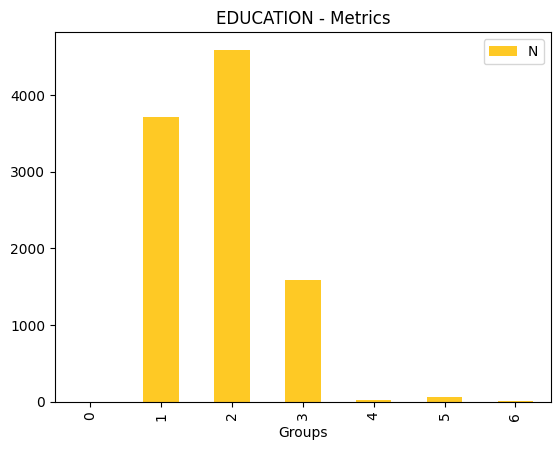

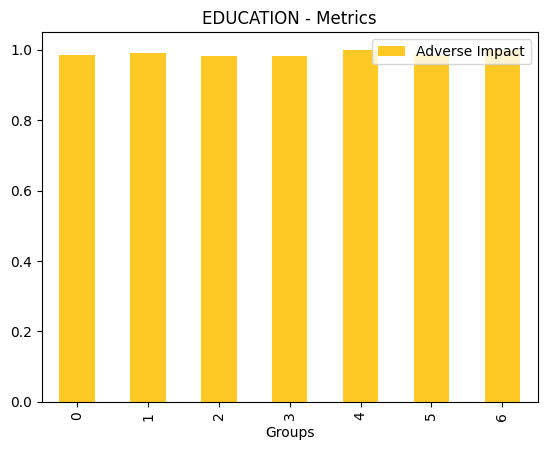

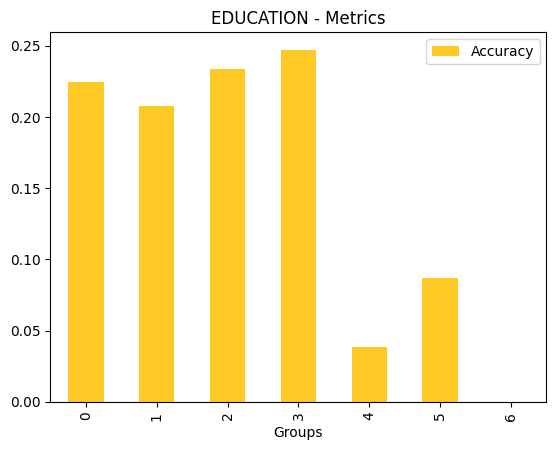

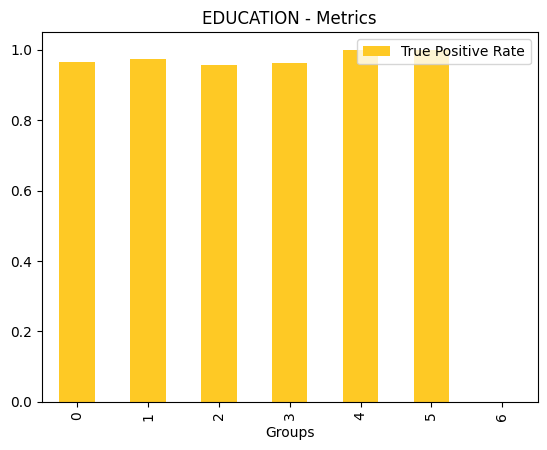

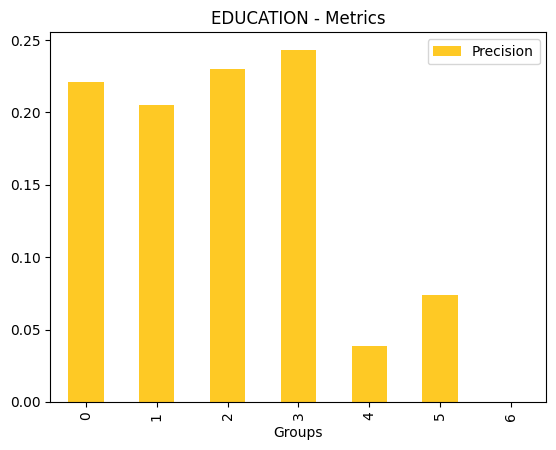

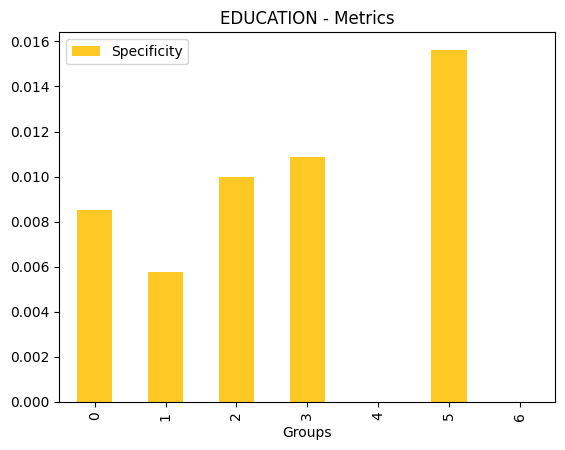

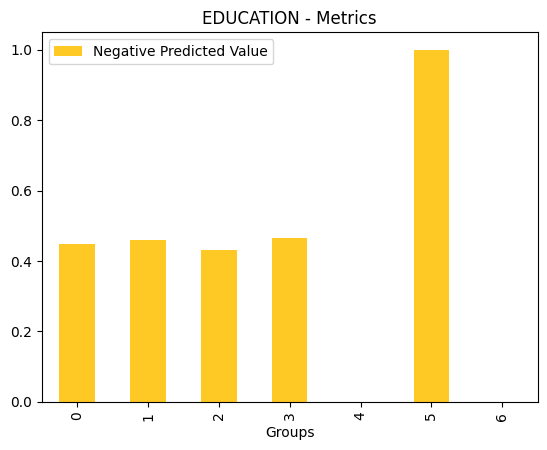

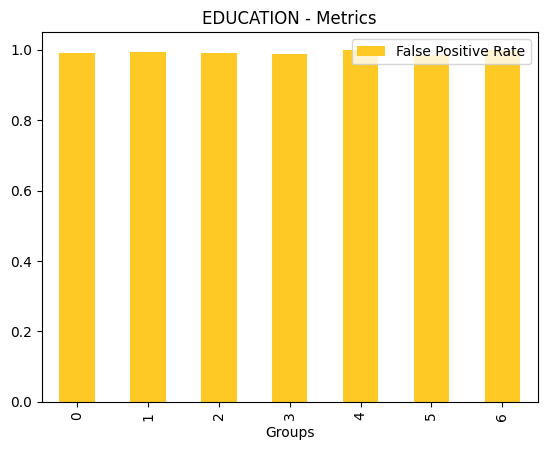

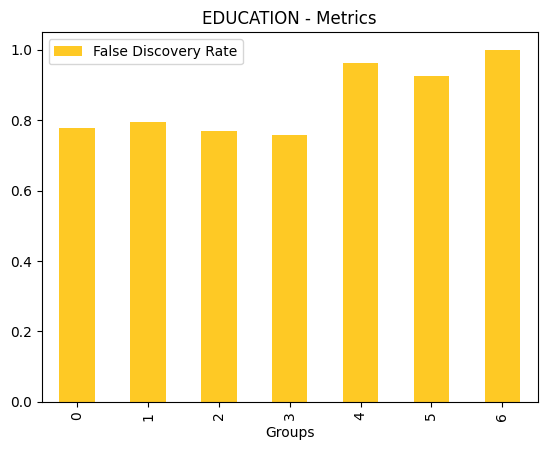

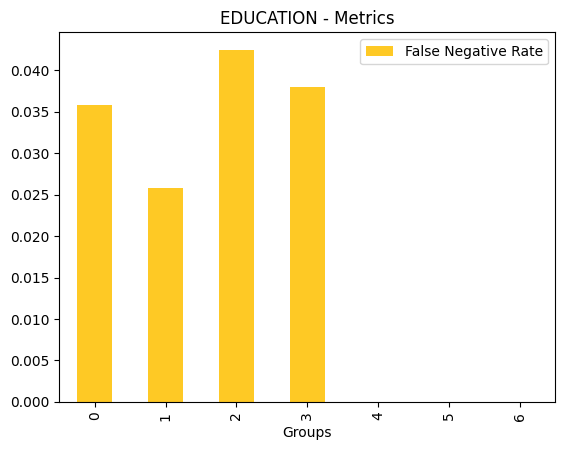

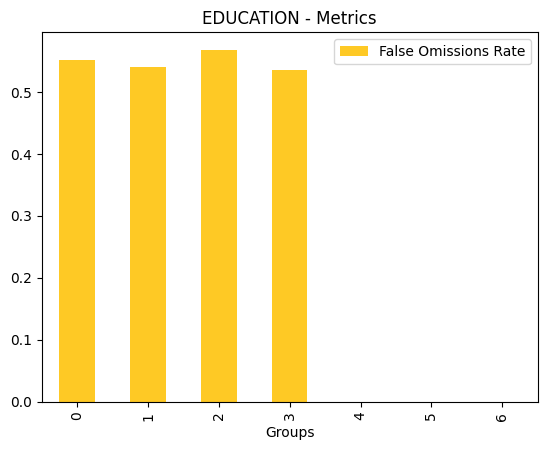

[]

In [16]:
result.plot(feature_name="EDUCATION")

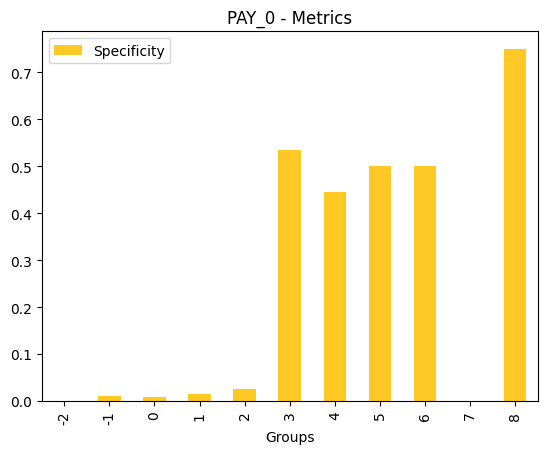

[]

In [17]:
# Only plot metric for "Specificity"
result.plot(feature_name="PAY_0", metrics_of_interest="Specificity")

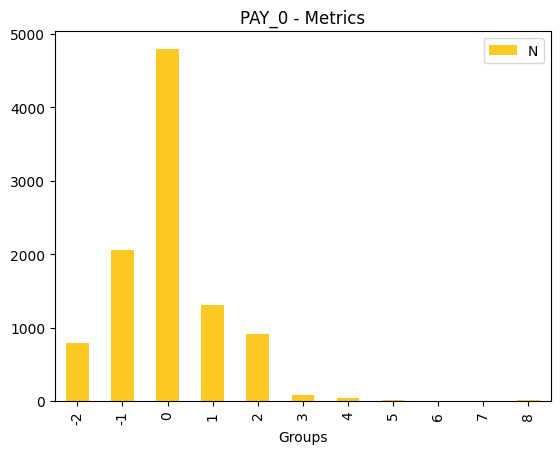

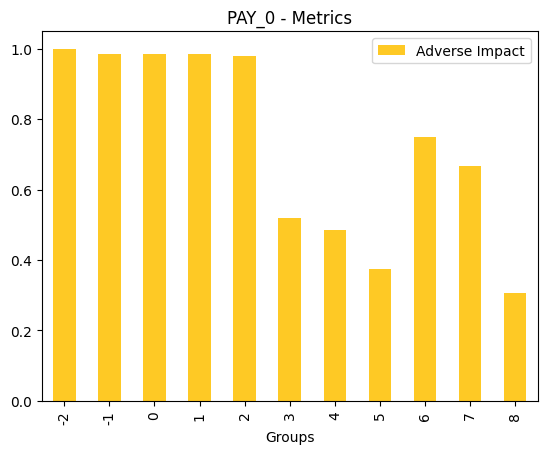

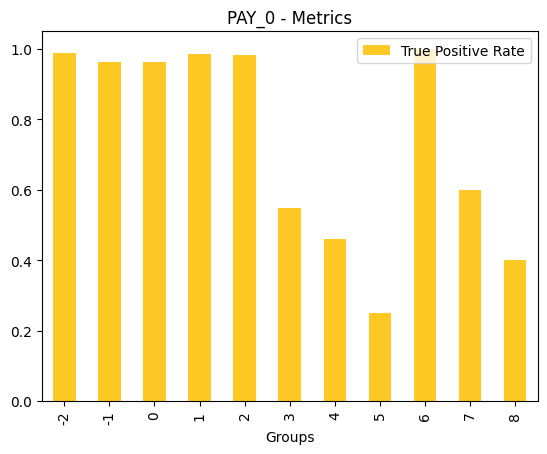

[]

In [18]:
# Only plot metrics for "N", "Adverse Impact" and "True Positive Rate"
result.plot(feature_name="PAY_0", metrics_of_interest=["N", "Adverse Impact", "True Positive Rate"])

### Save the explainer log and data

In [19]:
# save the explainer log
result.log(path="./dia-demo.log")

In [20]:
!head dia-demo.log

In [21]:
# save the explainer data
result.zip(file_path="./dia-demo-archive.zip")

In [22]:
!unzip -l dia-demo-archive.zip

Archive:  dia-demo-archive.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
     3988  2026-01-29 16:02   explainer_h2o_sonar_explainers_dia_explainer_DiaExplainer_2dc47eb0-225e-42cd-8b6a-b769177e05be/result_descriptor.json
      117  2026-01-29 16:01   explainer_h2o_sonar_explainers_dia_explainer_DiaExplainer_2dc47eb0-225e-42cd-8b6a-b769177e05be/global_disparate_impact_analysis/text_plain.meta
       19  2026-01-29 16:01   explainer_h2o_sonar_explainers_dia_explainer_DiaExplainer_2dc47eb0-225e-42cd-8b6a-b769177e05be/global_disparate_impact_analysis/text_plain/explanation.txt
        2  2026-01-29 16:02   explainer_h2o_sonar_explainers_dia_explainer_DiaExplainer_2dc47eb0-225e-42cd-8b6a-b769177e05be/problems/problems_and_actions.json
      110  2026-01-29 16:01   explainer_h2o_sonar_explainers_dia_explainer_DiaExplainer_2dc47eb0-225e-42cd-8b6a-b769177e05be/global_html_fragment/text_html.meta
    15297  2026-01-29 16:01   explainer_h2o_sonar_explainers_dia_explai